# R05 - Predictions with Quantile Regression

In [176]:
# Import libraries and set a random state
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time
import lime, shap
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, cross_validate, GridSearchCV
from sklearn.linear_model import QuantileRegressor
import warnings
warnings.filterwarnings('ignore')
# random_state = random.randint(1,30)
random_state = 8;  dropna_type = 1;  subset_type = 1;  column_type = 15;  cv_fold = 5

In [177]:
# Read the salary dataset, drop 'id' duplicates
salaries = pd.read_csv('Salaries_v4_202412161100(expanded).csv')
# salaries = pd.read_csv('Salaries_v3_202410141100(expanded_3).csv')
# salaries = pd.read_csv('Salaries_v3_202410141100(expanded_2).csv')
# salaries = pd.read_csv('Salaries_v3_202410141100(expanded).csv')
# salaries = pd.read_csv('Salaries_v3_202408271150(expanded).csv')
# salaries = pd.read_csv('Salaries_v3_202408021730(expanded).csv')
# salaries = pd.read_csv('Salaries_v3_202402121435.csv')
# salaries = pd.read_csv('Salaries_v3_202401081515.csv')
salaries = salaries.drop_duplicates('id').reset_index()
salaries = salaries.drop(['index','Unnamed: 0'],axis=1)
print("### COUNTS OF MISSING VALUES FOR DEFAULT COLUMNS ###")
print(salaries.isnull().sum()[:16])

### COUNTS OF MISSING VALUES FOR DEFAULT COLUMNS ###
id                      0
found_country           0
title                  12
position                0
employment_type      7157
company              2618
company_score        3815
edu_degrees           554
edu_degrees_major     931
working_year            0
education_score      4598
ms_counts               0
skill_counts            0
main_skills             0
skills                  0
amount_usd              0
dtype: int64


## Select Dropping of Missing Values Strategy

In [178]:
if dropna_type == 1:    print("ROWS WITH MISSING VALUES ARE NOT DROPPED");  
elif dropna_type == 2:  print("DROPPED ALL ROWS WITH MISSING VALUES");  salaries.dropna(inplace=True)
elif dropna_type == 3:  print("DROPPED ROWS WITH MISSING found_country");  salaries.dropna(subset=['found_country'], inplace=True)
elif dropna_type == 4:  print("DROPPED ROWS WITH MISSING title");  salaries.dropna(subset=['title'], inplace=True)
elif dropna_type == 5:  
    print("DROPPED ROWS WITH MISSING employment_type");  salaries.dropna(axis=0, subset=['employment_type'], inplace=True)
elif dropna_type == 6:  print("DROPPED ROWS WITH MISSING company");  salaries.dropna(axis=0, subset=['company'], inplace=True)
elif dropna_type == 7:  
    print("DROPPED ROWS WITH MISSING company_score");  salaries.dropna(axis=0, subset=['company_score'], inplace=True)
elif dropna_type == 8:  print("DROPPED ROWS WITH MISSING edu_degrees");  salaries.dropna(axis=0, subset=['edu_degrees'], inplace=True)
elif dropna_type == 9:  
    print("DROPPED ROWS WITH MISSING edu_degrees_major");  salaries.dropna(axis=0, subset=['edu_degrees_major'], inplace=True)
elif dropna_type == 10:  
    print("DROPPED ROWS WITH MISSING education_score");  salaries.dropna(axis=0, subset=['education_score'], inplace=True)
else:  raise ValueError('Drop N/A type must be between 1 and 10!')

print("This salary dataset contains {} ROWS & {} COLUMNS (DROP N/A TYPE: {})".format(
    salaries.shape[0], salaries.shape[1], dropna_type))

ROWS WITH MISSING VALUES ARE NOT DROPPED
This salary dataset contains 19554 ROWS & 135 COLUMNS (DROP N/A TYPE: 1)


## Dataset Information

In [179]:
# Get the first few rows of the dataset
salaries.head()

,id,found_country,title,position,employment_type,company,company_score,edu_degrees,edu_degrees_major,working_year,...,skill_leadership,skill_data_anly,skill_cpp,skill_javascript,skill_cust_serv,skill_mac_learn,skill_research,skill_proj_man,skill_html,skill_communication
0,0000083c-7054-4a2b-b675-6ac664c66bfb,United States,"Software Developer II at Audible, Inc.",Software Developer II,Full-time,"Audible, Inc.",8.9,"HIGH_SCHOOL,MASTERS,UNDERGRADUATE","Bachelor’s Degree, Computer Science,High Schoo...",11,...,0,0,1,0,0,0,0,0,1,0
1,00013847-ecf1-4a5a-ba44-16475dc28eba,United States,Retail Associate at Converse,Retail Associate,Full-time,NaN,NaN,UNDERGRADUATE,NaN,5,...,0,0,0,0,1,0,0,0,0,1
2,00018332-5b5d-4c23-88f8-1c2cdc133e28,United Kingdom,Test Engineer at Sky,Test Engineer,Full-time,NaN,NaN,UNDERGRADUATE,"Bachelor of Science (BSc), Computer Software E...",12,...,0,0,0,0,0,0,0,0,0,1
3,000c1054-ab28-4c4d-90b0-fa4b1ed31a2a,United States,Hardware Engineer at Google,Hardware Engineer,NaN,Google,8.7,MASTERS,"Master of Science (MS), Computer Engineering",13,...,0,0,0,0,0,0,0,0,0,0
4,00145b03-e286-4bdc-9063-ed5d2095306a,United States,BI Engineer @ Amazon | MS,BIE II,NaN,Amazon,8.4,MASTERS,"Master of Science - MS, Data Analytics",3,...,0,0,0,1,0,0,1,0,0,0


In [180]:
# Get necessary info about the dataset
salaries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19554 entries, 0 to 19553
Columns: 135 entries, id to skill_communication
dtypes: float64(27), int64(98), object(10)
memory usage: 20.1+ MB


In [181]:
# Get stats about the numerical columns
salaries.describe()

,company_score,working_year,education_score,ms_counts,skill_counts,amount_usd,country_coef,country_usa,country_uk,title_slr_coef,...,skill_leadership,skill_data_anly,skill_cpp,skill_javascript,skill_cust_serv,skill_mac_learn,skill_research,skill_proj_man,skill_html,skill_communication
count,15739.000000,19554.000000,14956.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,...,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000
mean,8.248993,11.449882,8.401484,15.738008,18.777948,163366.552981,0.966054,0.912959,0.087041,0.452360,...,0.258055,0.211824,0.197095,0.177202,0.179094,0.153370,0.205840,0.168252,0.169275,0.193157
std,0.561583,7.213469,1.383108,7.306042,7.814769,81118.159433,0.109942,0.281902,0.281902,0.145708,...,0.437575,0.408611,0.397815,0.381849,0.383441,0.360353,0.404325,0.374099,0.375004,0.394786
min,3.800000,0.000000,1.600000,1.000000,1.000000,21000.000000,0.610000,0.000000,0.000000,0.102000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.100000,6.000000,7.500000,11.000000,15.000000,102000.000000,1.000000,1.000000,0.000000,0.350000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,8.400000,10.000000,8.600000,16.000000,20.000000,150000.000000,1.000000,1.000000,0.000000,0.484000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8.600000,15.000000,9.700000,20.000000,20.000000,210000.000000,1.000000,1.000000,0.000000,0.539000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,10.000000,57.000000,10.000000,56.000000,82.000000,560000.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Select Rows / Columns & Make Train-Test Splits

In [182]:
## GET ANY SUBSET OF THE DATASET
if subset_type == 1:  print("FULL DATASET IS BEING USED")
## Countries
elif subset_type == 2:  print("SUBSET: country_usa");  salaries = salaries[salaries['country_usa'] == 1]
elif subset_type == 3:  print("SUBSET: country_uk");  salaries = salaries[salaries['country_uk'] == 1]
## Titles
elif subset_type == 4:  print("SUBSET: title_has_seniority");  salaries = salaries[salaries['title_has_seniority'] == 1]
elif subset_type == 5:  print("SUBSET: tt_software_eng");  salaries = salaries[salaries['tt_software_eng'] == 1]
elif subset_type == 6:  print("SUBSET: tt_data_analyst");  salaries = salaries[salaries['tt_data_analyst'] == 1]
elif subset_type == 7:  print("SUBSET: tt_data_scientist");  salaries = salaries[salaries['tt_data_scientist'] == 1]
elif subset_type == 8:  print("SUBSET: tt_machine_learning");  salaries = salaries[salaries['tt_machine_learning'] == 1]
elif subset_type == 9:  print("SUBSET: tt_program_manager");  salaries = salaries[salaries['tt_program_manager'] == 1]
## Positions
elif subset_type == 10:  print("SUBSET: position_has_seniority");  salaries = salaries[salaries['position_has_seniority'] == 1]
elif subset_type == 11:  print("SUBSET: pos_software_eng");  salaries = salaries[salaries['pos_software_eng'] == 1]
elif subset_type == 12:  print("SUBSET: pos_data_analyst");  salaries = salaries[salaries['pos_data_analyst'] == 1]
elif subset_type == 13:  print("SUBSET: pos_machine_learning");  salaries = salaries[salaries['pos_machine_learning'] == 1]
elif subset_type == 14:  print("SUBSET: pos_program_manager");  salaries = salaries[salaries['pos_program_manager'] == 1]
elif subset_type == 15:  print("SUBSET: pos_network_engineer");  salaries = salaries[salaries['pos_network_engineer'] == 1]
## Educations
elif subset_type == 16:  print("SUBSET: phd_degree");  salaries = salaries[salaries['phd_degree'] == 1]
elif subset_type == 17:  print("SUBSET: master_degree");  salaries = salaries[salaries['master_degree'] == 1]
elif subset_type == 18:  print("SUBSET: undergrad_degree");  salaries = salaries[salaries['undergrad_degree'] == 1]
## Companies
elif subset_type == 19:  print("SUBSET: comp_google");  salaries = salaries[salaries['comp_google'] == 1]
elif subset_type == 20:  print("SUBSET: comp_amazon");  salaries = salaries[salaries['comp_amazon'] == 1]
elif subset_type == 21:  print("SUBSET: comp_oracle");  salaries = salaries[salaries['comp_oracle'] == 1]
elif subset_type == 22:  print("SUBSET: comp_microsoft");  salaries = salaries[salaries['comp_microsoft'] == 1]
elif subset_type == 23:  print("SUBSET: comp_apple");  salaries = salaries[salaries['comp_apple'] == 1]
elif subset_type == 24:  print("SUBSET: comp_linkedin");  salaries = salaries[salaries['comp_linkedin'] == 1]
## Main Skills
elif subset_type == 25:  print("SUBSET: ms_python");  salaries = salaries[salaries['ms_python'] == 1]
elif subset_type == 26:  print("SUBSET: ms_data_eng");  salaries = salaries[salaries['ms_data_eng'] == 1]
elif subset_type == 27:  print("SUBSET: ms_java");  salaries = salaries[salaries['ms_java'] == 1]
elif subset_type == 28:  print("SUBSET: ms_cpp");  salaries = salaries[salaries['ms_cpp'] == 1]
elif subset_type == 29:  print("SUBSET: ms_mac_learn");  salaries = salaries[salaries['ms_mac_learn'] == 1]
elif subset_type == 30:  print("SUBSET: ms_software_dev");  salaries = salaries[salaries['ms_software_dev'] == 1]
else:  raise ValueError('Salaries subset type must be between 1 and 30!')

# Fill the null values with average for some columns
salaries['company_score'] = salaries['company_score'].fillna(salaries['company_score'].mean())
salaries['education_score'] = salaries['education_score'].fillna(salaries['education_score'].mean())

## GET ANY SUBCOLUMNS OF THE DATASET
if column_type == 1:
    print("BASE NUMERICAL COLUMNS")
    salaries = salaries[['company_score','working_year','education_score','ms_counts','skill_counts','country_coef','amount_usd']]
elif column_type == 2:
    print("ALL NUMERICAL COLUMNS")
    salaries = salaries[['company_score','working_year','education_score','ms_counts','skill_counts','country_coef','country_usa', \
                         'country_uk','title_has_seniority','tt_software_eng','tt_data_analyst','tt_data_scientist', \
                         'tt_machine_learning','tt_program_manager','tt_bi_engineer','tt_ux_ui_designer','tt_app_dev_eng', \
                         'tt_bi_analyst','tt_devops_eng','tt_network_eng','tt_product_manager','tt_qa_engineer', \
                         'position_has_seniority','pos_software_eng','pos_data_analyst','pos_data_scientist', \
                         'pos_machine_learning','pos_program_manager','pos_network_engineer','pos_product_manager', \
                         'pos_project_manager','pos_ux_ui_designer','pos_business_analyst','pos_devops_eng',
                         'employment_full_time','highest_edu_deg_lvl','phd_degree','master_degree','undergrad_degree', \
                         'ed_arts','ed_business_admin','ed_computer_eng','ed_computer_science','ed_electric_electronic', \
                         'ed_info_tech','ed_math','ed_philosophy','comp_amazon','comp_google','comp_oracle','comp_microsoft', \
                         'comp_meta','comp_apple','comp_cisco','comp_aws','comp_ibm','comp_linkedin','comp_capitalone', \
                         'comp_jpmorgan','comp_intel','comp_saic','comp_tata','comp_intuit','comp_uber','comp_qualcomm', \
                         'comp_salesforce','comp_stripe','ms_fin_man','ms_python','ms_data_eng','ms_sql','ms_programming', \
                         'ms_java','ms_office','ms_data_anly','ms_leadership','ms_cpp','ms_javascript','ms_market_res', \
                         'ms_html','ms_mac_learn','ms_proj_man','ms_software_dev','ms_cust_serv','ms_research', \
                         'skill_office','skill_sql','skill_java','skill_python','skill_leadership','skill_data_anly', \
                         'skill_cpp','skill_javascript','skill_cust_serv','skill_mac_learn','skill_research','skill_proj_man', \
                         'skill_html','skill_communication','amount_usd']]
elif column_type == 3:
    print("NUMERICAL COLUMNS ONLY WITH >=0.1 CORRELATION")
    salaries = salaries[['company_score','working_year','education_score','country_coef','country_usa','title_has_seniority', \
                         'tt_data_scientist','tt_machine_learning','tt_program_manager','tt_product_manager', \
                         'position_has_seniority','pos_data_scientist','pos_machine_learning','pos_program_manager', \
                         'pos_product_manager','highest_edu_deg_lvl','phd_degree','master_degree','undergrad_degree', \
                         'ed_computer_eng','ed_computer_science','ed_electric_electronic','ed_philosophy', \
                         'comp_google','comp_apple','comp_linkedin','comp_stripe','ms_python','ms_data_eng','ms_sql', \
                         'ms_cpp','ms_mac_learn','ms_software_dev','skill_sql','skill_python','skill_cpp','skill_mac_learn', \
                         'amount_usd']]
elif column_type == 4:
    print("TITLE COLUMNS ONLY")
    salaries = salaries[['title_has_seniority','tt_software_eng','tt_data_analyst','tt_data_scientist','tt_machine_learning', \
                         'tt_program_manager','tt_bi_engineer','tt_ux_ui_designer','tt_app_dev_eng','tt_bi_analyst', \
                         'tt_devops_eng','tt_network_eng','tt_product_manager','tt_qa_engineer','amount_usd']]
elif column_type == 5:
    print("POSITION COLUMNS ONLY")
    salaries = salaries[['position_has_seniority','pos_software_eng','pos_data_analyst','pos_data_scientist', \
                         'pos_machine_learning','pos_program_manager','pos_network_engineer','pos_product_manager', \
                         'pos_project_manager','pos_ux_ui_designer','pos_business_analyst','pos_devops_eng','amount_usd']]
elif column_type == 6:
    print("EDUCATION DEGREE COLUMNS ONLY")
    salaries = salaries[['highest_edu_deg_lvl','phd_degree','master_degree','undergrad_degree','amount_usd']]
elif column_type == 7:
    print("EDUCATION DEGREE MAJOR COLUMNS ONLY")
    salaries = salaries[['ed_arts','ed_business_admin','ed_computer_eng','ed_computer_science','ed_electric_electronic', \
                         'ed_info_tech','ed_math','ed_philosophy','amount_usd']]
elif column_type == 8:
    print("COMPANY COLUMNS ONLY")
    salaries = salaries[['comp_amazon','comp_google','comp_oracle','comp_microsoft','comp_meta','comp_apple','comp_cisco', \
                         'comp_aws','comp_ibm','comp_linkedin','comp_capitalone','comp_jpmorgan','comp_intel','comp_saic', \
                         'comp_tata','comp_intuit','comp_uber','comp_qualcomm','comp_salesforce','comp_stripe','amount_usd']]
elif column_type == 9:
    print("MAIN SKILL COLUMNS ONLY")
    salaries = salaries[['ms_fin_man','ms_python','ms_data_eng','ms_sql','ms_programming','ms_java','ms_office', \
                         'ms_data_anly','ms_leadership','ms_cpp','ms_javascript','ms_market_res','ms_html','ms_mac_learn', \
                         'ms_proj_man','ms_software_dev','ms_cust_serv','ms_research','amount_usd']]
elif column_type == 10:
    print("SKILL COLUMNS ONLY")
    salaries = salaries[['skill_office','skill_sql','skill_java','skill_python','skill_leadership','skill_data_anly', \
                         'skill_cpp','skill_javascript','skill_cust_serv','skill_mac_learn','skill_research','skill_proj_man', \
                         'skill_html','skill_communication','amount_usd']]
elif column_type == 11:
    print("MOST POSITIVELY AND NEGATIVELY CORRELATED COLUMNS ONLY (BOTH TOP 10)")
    salaries = salaries[['company_score','position_has_seniority','comp_google','country_usa','country_coef', \
                         'title_has_seniority','comp_linkedin','highest_edu_deg_lvl','master_degree','phd_degree', \
                         'country_uk','ms_cust_serv','skill_cust_serv','skill_communication','ms_office', \
                         'skill_office','skill_leadership','ms_leadership','ms_fin_man','pos_data_analyst','amount_usd']]
elif column_type == 12:
    print("MOST POSITIVELY AND NEGATIVELY CORRELATED COLUMNS ONLY (BOTH TOP 20)")
    salaries = salaries[['company_score','position_has_seniority','comp_google','country_usa','country_coef', \
                         'title_has_seniority','comp_linkedin','highest_edu_deg_lvl','master_degree','phd_degree', \
                         'education_score','skill_mac_learn','ms_mac_learn','skill_cpp','ms_cpp', \
                         'working_year','skill_python','ed_philosophy','ms_python','pos_data_scientist', \
                         'country_uk','ms_cust_serv','skill_cust_serv','skill_communication','ms_office', \
                         'skill_office','skill_leadership','ms_leadership','ms_fin_man','pos_data_analyst', \
                         'tt_data_analyst','tt_bi_analyst','comp_tata','pos_business_analyst','comp_jpmorgan', \
                         'employment_full_time','ed_arts','comp_ibm','ed_business_admin','skill_counts','amount_usd']]
elif column_type == 13:
    print("TOP 25 POSITIVELY CORRELATED COLUMNS (BASED ON DATETIME 2024-10-14)")
    salaries = salaries [['company_score','position_has_seniority','comp_google','country_usa','country_coef', \
                         'title_has_seniority','comp_linkedin','highest_edu_deg_lvl','master_degree','phd_degree', \
                         'education_score','skill_mac_learn','ms_mac_learn','skill_cpp','ms_cpp', \
                         'working_year','skill_python','ed_philosophy','ms_python','pos_data_scientist', \
                         'ed_computer_science','pos_machine_learning','tt_product_manager','tt_machine_learning','pos_product_manager', \
                         'amount_usd']]
elif column_type == 14:
    print("TOP 25 NEGATIVELY CORRELATED COLUMNS (BASED ON DATETIME 2024-10-14)")
    salaries = salaries[['country_uk','ms_cust_serv','skill_cust_serv','skill_communication','ms_office', \
                         'skill_office','skill_leadership','ms_leadership','ms_fin_man','pos_data_analyst', \
                         'tt_data_analyst','tt_bi_analyst','comp_tata','pos_business_analyst','comp_jpmorgan', \
                         'employment_full_time','ed_arts','comp_ibm','ed_business_admin','skill_counts', \
                         'ms_counts','ms_market_res','comp_saic','tt_qa_engineer','ms_research','amount_usd']]
elif column_type == 15:
    print("BASE NUMERICAL AND NORMALIZED COLUMNS TOGETHER")
    salaries = salaries[['company_score','working_year','education_score','ms_counts','skill_counts','country_coef', \
                         'title_slr_coef','title_seniority_slr_coef','position_slr_coef','position_seniority_slr_coef', \
                         'employment_type_coef','employment_type_slr_coef','highest_edu_deg_lvl','edu_deg_slr_coef', \
                         'edu_degree_major_coef_max','company_slr_coef','main_skill_slr_coef_avg','amount_usd']]
else:
    raise ValueError('Salaries column type must be between 1 and 15!')

print("SUBSET TYPE:", subset_type, "  COLUMN TYPE:", column_type, "  DATASET SHAPE:", salaries.shape)

FULL DATASET IS BEING USED
BASE NUMERICAL AND NORMALIZED COLUMNS TOGETHER
SUBSET TYPE: 1   COLUMN TYPE: 15   DATASET SHAPE: (19554, 18)


In [183]:
# OPTION 1: Make train and test splits; 90% train and 10% test
random_state_in_use = True
X = salaries.drop('amount_usd',axis=1)
y = salaries['amount_usd']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=random_state)
print("TRAIN SIZE:", x_train.shape, y_train.shape, " TEST SIZE:", x_test.shape, y_test.shape)

TRAIN SIZE: (17598, 17) (17598,)  TEST SIZE: (1956, 17) (1956,)


In [184]:
# OPTION 2: Separate train and test sets with exact boundary
# random_state_in_use = False
# X = salaries_alt.drop('amount_usd',axis=1)
# y = salaries_alt['amount_usd']
# x_train = X[:9000];   y_train = y[:9000]
# x_test = X[9000:];    y_test = y[9000:]
# print("TRAIN SIZE:", x_train.shape, y_train.shape, " TEST SIZE:", x_test.shape, y_test.shape)

## Create the Model & Evaluate the Predictions

In [185]:
# QUANTILE REGRESSION: Linear regression model that predicts conditional quantiles
# The linear QuantileRegressor optimizes the pinball loss for a desired quantile and is robust to outliers.
# This model uses an L1 regularization like Lasso.
# NOTE: Recommended to give alpha value as '0', otherwise, it's very difficult to get coefficients other than zero!
# Also, don't select 'interior-point' as the solver, because it doesn't complete and can consume several GB of memory!
qr = QuantileRegressor(quantile=0.5, alpha=0, solver='highs-ds')
qr.get_params()
# quantile: float, default = 0.5
# alpha: float, default = 1.0
# fit_intercept: bool, default = True
# solver: {'highs-ds', 'highs-ipm', 'highs', 'interior-point', 'revised simplex'}, default = 'interior-point'
# solver_options: dict, default = None

{'alpha': 0,
 'fit_intercept': True,
 'quantile': 0.5,
 'solver': 'highs-ds',
 'solver_options': None}

In [186]:
# Fit the training data into the quantile model, then make predictions on the test data
s_time = time.time()
qr.fit(x_train, y_train)
print("FITTING TIME: {:.4f} seconds".format(time.time()-s_time))
s_time = time.time()
y_pred = qr.predict(x_test)
print("PREDICTION TIME: {:.4f} seconds.".format(time.time()-s_time))

FITTING TIME: 20.8174 seconds
PREDICTION TIME: 0.0026 seconds.


In [187]:
print("COEF:", qr.coef_)   # Estimated coefficients for the features
print("INTERCEPT:", qr.intercept_)   # The intercept of the model, a.k.a. bias term
print("FEATURES:", qr.n_features_in_)   # Number of features seen during fit
print("ITERATIONS:", qr.n_iter_)   # The actual number of iterations performed by the solver

COEF: [ 1.51710455e+04  1.88500670e+03  1.31457560e+03 -9.46131890e+01
  4.40895089e+01  1.88773845e+05  1.58177418e+05  1.62749912e+04
  1.14164874e+05  9.44815797e+04  1.15430992e+04 -1.41119717e+04
  6.15931753e+02  1.87259259e+04  3.31332265e+03  9.20007960e+04
  2.92749121e+04]
INTERCEPT: -450152.5608727119
FEATURES: 17
ITERATIONS: 18044


In [188]:
def adjusted_r2_score(r2_score, n, k):
    return 1 - (1-r2_score)*(n-1)/(n-k-1)

In [189]:
# Results of metrics
if random_state_in_use:
    print("### RESULTS OF METRICS -> RANDOM STATE {} | DROP NA TYPE {} | SUBSET TYPE {} | COLUMN TYPE {} || SIZE {}/{}/{} ###".format(
        random_state, dropna_type, subset_type, column_type, salaries.shape[0], x_train.shape[0], x_test.shape[0]))
else:   print("### SCORES FOR CUSTOM TRAIN-TEST SETS ###")
print("MSE: ", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))
print("MAE: ", mean_absolute_error(y_test, y_pred))
print("R2 SCORE:", r2_score(y_test, y_pred))
print("ADJUSTED R2 SCORE:", adjusted_r2_score(r2_score(y_test, y_pred), len(y_test), X.shape[1]))

### RESULTS OF METRICS -> RANDOM STATE 8 | DROP NA TYPE 1 | SUBSET TYPE 1 | COLUMN TYPE 15 || SIZE 19554/17598/1956 ###
MSE:  2218575360.986111
RMSE: 47101.75539176975
MAE:  33981.48283085455
R2 SCORE: 0.6455921474045183
ADJUSTED R2 SCORE: 0.6424833065922773


In [190]:
# Results of cross validation
s_time = time.time()
cross_val = cross_validate(qr, X, y, cv=cv_fold, return_train_score=True)
print("### CROSS VALIDATION ({}-FOLD) ###".format(cv_fold))
# The time in seconds for fitting the estimator on the train set for each cv split
print("FITTING TIME: {} -> {:.8f}".format(cross_val['fit_time'], cross_val['fit_time'].mean()))
# The time in seconds for scoring the estimator on the test set for each cv split
print("SCORING TIME: {} -> {:.8f}".format(cross_val['score_time'], cross_val['score_time'].mean()))
# The score array for train scores for each cv split
print("TRAIN SCORE:  {} -> {:.8f}".format(cross_val['train_score'], cross_val['train_score'].mean()))
# The score array for test score for each cv split
print("TEST SCORE:   {} -> {:.8f}".format(cross_val['test_score'], cross_val['test_score'].mean()))     
print("Cross validation was completed in {:.3f} seconds.".format(time.time()-s_time))

### CROSS VALIDATION (5-FOLD) ###
FITTING TIME: [15.45841289 15.54894209 15.08698201 15.07140613 15.1155777 ] -> 15.25626416
SCORING TIME: [0.00199318 0.0030663  0.00200796 0.00303936 0.00195789] -> 0.00241294
TRAIN SCORE:  [0.66757387 0.67076535 0.66912317 0.66738076 0.66703968] -> 0.66837657
TEST SCORE:   [0.66919241 0.65855112 0.66739253 0.67107059 0.67248603] -> 0.66773853
Cross validation was completed in 76.319 seconds.


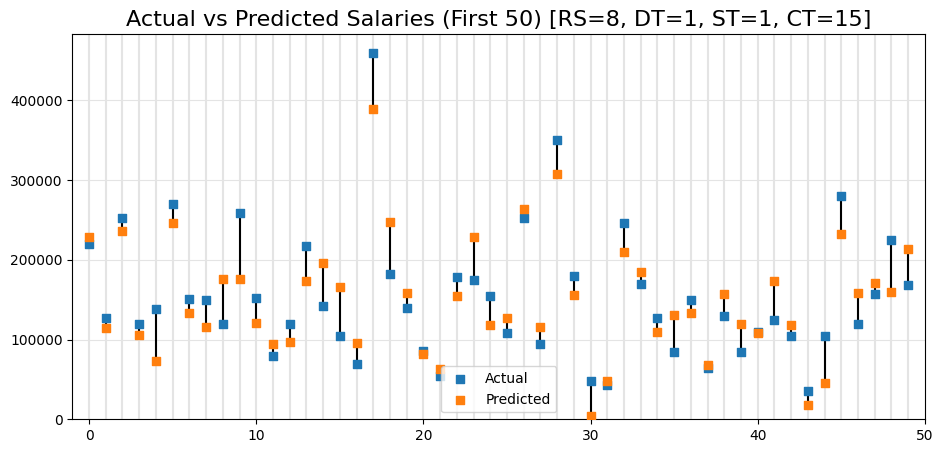

In [191]:
# Compare the predicted salaries against the actual ones in a visualization, for the first 50 salaries of the test set
if x_test.shape[0] < 50:  rows = x_test.shape[0]
else:  rows = 50
plt.figure(figsize=(11,5))
plt.axis([-1,rows,0,y_test.iloc[:rows].max()*1.05])
for i in range(rows):
    # print("{:20} | {:8}".format(y_pred[i], y_test.iloc[i]))
    plt.axvline(i, color='#e4e4e4', zorder=2)
plt.scatter(range(rows), y_test.iloc[:rows], marker='s',label='Actual', zorder=4)
plt.scatter(range(rows), y_pred[:rows], marker='s',label='Predicted', zorder=4)
plt.title("Actual vs Predicted Salaries (First {}) [RS={}, DT={}, ST={}, CT={}]".format(
    rows, random_state, dropna_type, subset_type, column_type), fontsize=16)
for i in range(rows):
    plt.axvline(i, ymin=y_test.iloc[i]/(y_test.iloc[:rows].max()*1.05), ymax=y_pred[i]/(y_test.iloc[:rows].max()*1.05), 
                color='black', zorder=3)
plt.legend()
plt.grid(color='#e4e4e4', axis='y', zorder=1)
plt.show()

## Explain the Model with SHAP

In [192]:
shap.initjs()
shap_explainer = shap.Explainer(qr, x_train)
shap_values = shap_explainer(x_test)
print(shap_values.shape)
print(shap_values)
print("\n EXPECTED VALUE:", shap_explainer.expected_value)

(1956, 17)
.values =
array([[   853.13828536,   6258.22225203,   -359.26939863, ...,
           402.27050314,  27073.07422716,   -366.46705142],
       [   853.13828536,  -8821.83136732,    -94.40298243, ...,
           -74.8479587 , -24907.37549026,  -4896.02782901],
       [  4661.17771032,   4373.21554961,   1481.1364449 , ...,
           740.2294136 ,  21369.02487763,   3437.31986322],
       ...,
       [  4661.17771032,  11913.24235929,    -94.40298243, ...,
           210.09778934,  21369.02487763,   2497.92046101],
       [   853.13828536,  -3166.81126006,    -94.40298243, ...,
          -263.70734984, -24907.37549026,  -1359.86240265],
       [ 15280.90958818,  -8821.83136732,   1744.05156541, ...,
          -469.13335425, -26655.3906135 ,  -1890.91958039]])

.base_values =
array([153102.33896424, 153102.33896424, 153102.33896424, ...,
       153102.33896424, 153102.33896424, 153102.33896424])

.data =
array([[ 8.24899295, 14.        ,  8.2       , ...,  0.854     ,
         0

### Global Explainability

### SUMMARY OF EXPLAINABILITY WITH SHAP ###


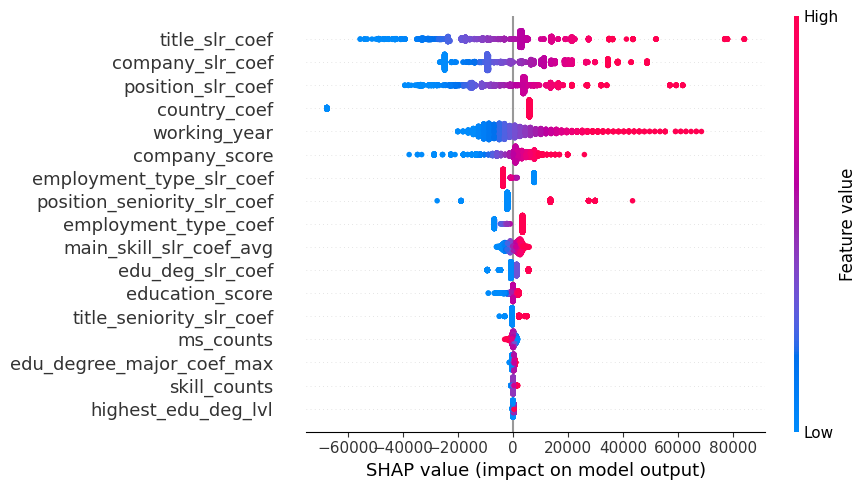

In [193]:
print("### SUMMARY OF EXPLAINABILITY WITH SHAP ###")
# shap.plots.beeswarm(shap_values)
shap.summary_plot(shap_values, x_test, plot_type='dot', plot_size=[9,5])

In [194]:
print("### VISUALIZATION OF FIRST 100 PREDICTIONS ###")
shap.plots.force(shap_values[:100])

### VISUALIZATION OF FIRST 100 PREDICTIONS ###


### MEAN ABSOLUTE VALUES OF SHAP VALUES ###


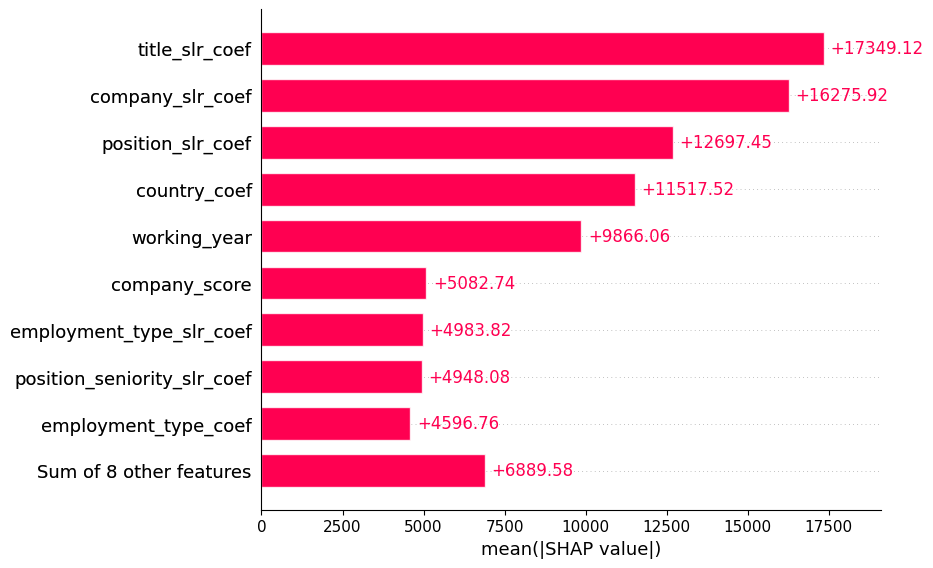

In [195]:
print("### MEAN ABSOLUTE VALUES OF SHAP VALUES ###")
shap.plots.bar(shap_values)

### DEPENDENCY BETWEEN THE FIRST COLUMN & THE BEST INTERACTION ###


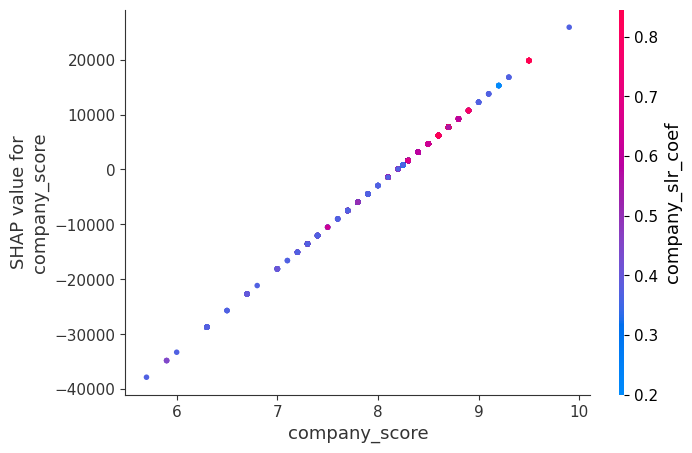

In [196]:
print("### DEPENDENCY BETWEEN THE FIRST COLUMN & THE BEST INTERACTION ###")
shap.dependence_plot(x_train.columns[0], shap_values.values, x_test)

### Local Explainability

### EXPLAINING TEST ROW 1090 WITH SHAP ###


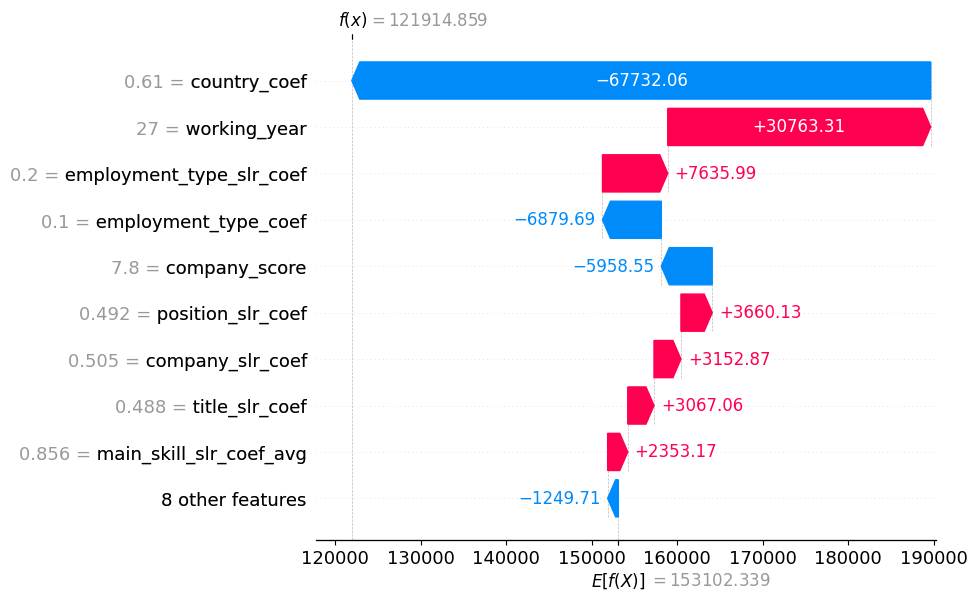

In [197]:
# i = 0
i = random.randint(0, x_test.shape[0]-1)
print("### EXPLAINING TEST ROW {} WITH SHAP ###".format(i))
shap.plots.waterfall(shap_values[i])

In [198]:
print("### EXPLAINING TEST ROW {} WITH SHAP ###".format(i))
shap.plots.force(shap_values[i])

### EXPLAINING TEST ROW 1090 WITH SHAP ###


## Explain the Model with LIME

In [199]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(x_train.values, feature_names=salaries.columns, 
                                                        class_names=['amount_usd'], verbose=True, mode='regression')

In [200]:
i = random.randint(0, x_test.shape[0]-1)
print("### EXPLAINING TEST ROW {} WITH LIME ###".format(i))
exp = lime_explainer.explain_instance(x_test.iloc[i], qr.predict, num_features=10)
exp.show_in_notebook(show_table=True)
exp.as_list()

### EXPLAINING TEST ROW 789 WITH LIME ###
Intercept 168674.3335914495
Prediction_local [140205.18862736]
Right: 165964.2737499334


[('position_seniority_slr_coef <= 0.52', -19869.634963579523),
 ('working_year <= 6.00', -18548.96348203357),
 ('company_score <= 8.20', -15294.382762340008),
 ('0.20 < employment_type_slr_coef <= 1.00', -13747.808012402478),
 ('0.54 < company_slr_coef <= 0.68', 12313.253760390397),
 ('0.10 < employment_type_coef <= 0.99', 11791.994319882815),
 ('0.48 < title_slr_coef <= 0.54', 8689.968937065045),
 ('0.49 < position_slr_coef <= 0.56', 8338.441078054126),
 ('title_seniority_slr_coef <= 0.49', -5798.176672651156),
 ('8.40 < education_score <= 9.50', 3656.162833525338)]